# Curriculum Learning on CIFAR-10
## Models: MobileNetV2 & EfficientNet-B0

Objective:
Train models by starting with easy samples and gradually introducing harder data.

## IMPORTS

In [18]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from torch.utils.data import Dataset, DataLoader, Subset

In [19]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## DATASET - CIFAR10

In [20]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [21]:
# Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).permute(0,3,1,2)
        self.labels = torch.tensor(labels, dtype=torch.long).squeeze()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

## DATALOADER

In [23]:
trainset = CIFAR10Dataset(x_train, y_train)
testset = CIFAR10Dataset(x_test, y_test)

trainloader_full = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## LOSS


In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
# COMPUTE SAMPLE LOSS
def compute_sample_losses(model, dataset):
    loader = DataLoader(dataset, batch_size=64)
    model.eval()

    losses = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = nn.CrossEntropyLoss(reduction='none')(outputs, labels)

            losses.extend(loss.cpu().numpy())

    return torch.tensor(losses)

## TRAIN FUNCTION (WITH VALIDATION)

In [26]:
def train_model(model, loader, testloader, optimizer, epochs):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        t_loss = running_loss / len(loader)
        t_acc = 100 * correct / total

        # VALIDATION
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                v_loss += loss.item()

                _, pred = torch.max(outputs, 1)
                v_total += labels.size(0)
                v_correct += (pred == labels).sum().item()

        v_loss /= len(testloader)
        v_acc = 100 * v_correct / v_total

        train_loss.append(t_loss)
        train_acc.append(t_acc)
        val_loss.append(v_loss)
        val_acc.append(v_acc)

        print(f"Epoch {epoch+1}: Train Acc={t_acc:.2f}% | Val Acc={v_acc:.2f}%")

    return train_loss, train_acc, val_loss, val_acc

## EVALUATE FUNCTION

In [27]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

## 1. MOBILE-NET

### MODEL

In [28]:
model_mob = models.mobilenet_v2(weights="DEFAULT")
model_mob.classifier[1] = nn.Linear(1280, 10)
model_mob = model_mob.to(device)

optimizer_mob = optim.Adam(model_mob.parameters(), lr=0.001)

train_model(model_mob, trainloader_full, testloader, optimizer_mob, epochs=2)

Epoch 1: Train Acc=62.80% | Val Acc=73.95%
Epoch 2: Train Acc=75.29% | Val Acc=78.67%


([1.094664235858966, 0.7365073949251029],
 [62.796, 75.286],
 [0.7635314464569092, 0.635284310123723],
 [73.95, 78.67])

### COMPUTE LOSSES

In [34]:
losses = compute_sample_losses(model_mob, trainset)
indices = torch.argsort(losses)

easy_subset = Subset(trainset, indices[:25000])
easy_loader = DataLoader(easy_subset, batch_size=64, shuffle=True)

### TRAIN

In [30]:
loss_mob1, acc_mob1, val_loss_mob1, val_acc_mob1 = train_model(
    model_mob, easy_loader, testloader, optimizer_mob, epochs=5
)

loss_mob2, acc_mob2, val_loss_mob2, val_acc_mob2 = train_model(
    model_mob, trainloader_full, testloader, optimizer_mob, epochs=5
)

loss_mob = loss_mob1 + loss_mob2
acc_mob = acc_mob1 + acc_mob2
val_loss_mob = val_loss_mob1 + val_loss_mob2
val_acc_mob = val_acc_mob1 + val_acc_mob2

Epoch 1: Train Acc=96.51% | Val Acc=76.06%
Epoch 2: Train Acc=96.78% | Val Acc=76.89%
Epoch 3: Train Acc=97.11% | Val Acc=76.35%
Epoch 4: Train Acc=97.25% | Val Acc=77.20%
Epoch 5: Train Acc=97.58% | Val Acc=77.14%
Epoch 1: Train Acc=77.78% | Val Acc=80.16%
Epoch 2: Train Acc=82.22% | Val Acc=81.36%
Epoch 3: Train Acc=83.93% | Val Acc=82.79%
Epoch 4: Train Acc=85.69% | Val Acc=81.21%
Epoch 5: Train Acc=86.81% | Val Acc=82.20%


### TEST ACCURACY

In [31]:
acc_mob_test = evaluate(model_mob, testloader)
print("MobileNet Curriculum Accuracy:", acc_mob_test)

MobileNet Curriculum Accuracy: 82.2


### GRAPHS

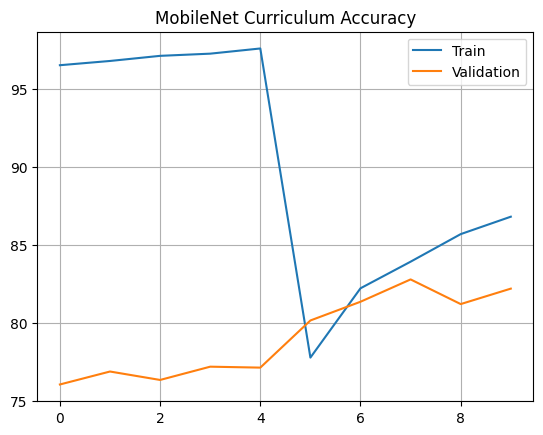

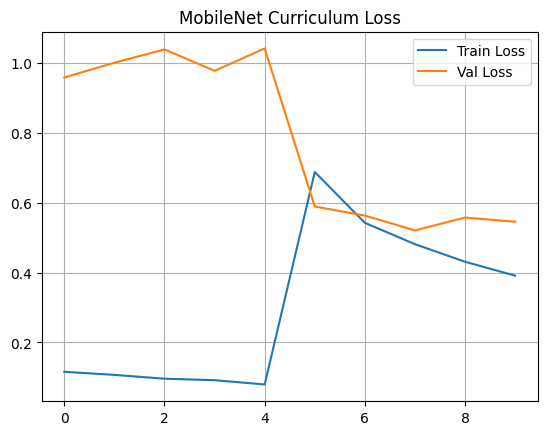

In [32]:
plt.plot(acc_mob, label="Train")
plt.plot(val_acc_mob, label="Validation")
plt.title("MobileNet Curriculum Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(loss_mob, label="Train Loss")
plt.plot(val_loss_mob, label="Val Loss")
plt.title("MobileNet Curriculum Loss")
plt.legend()
plt.grid()
plt.show()

### PREDICTION

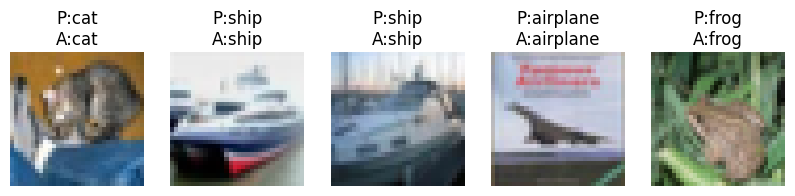

In [36]:
images, labels = next(iter(testloader))

images = images.to(device)

outputs = model_mob(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)

    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)

    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis("off")

plt.show()

## 2. EFFICIENT-NET

### MODEL

In [37]:
model_eff = models.efficientnet_b0(weights="DEFAULT")
model_eff.classifier[1] = nn.Linear(1280, 10)
model_eff = model_eff.to(device)

optimizer_eff = optim.Adam(model_eff.parameters(), lr=0.001)

train_model(model_eff, trainloader_full, testloader, optimizer_eff, epochs=2)

Epoch 1: Train Acc=64.97% | Val Acc=76.37%
Epoch 2: Train Acc=78.38% | Val Acc=79.88%


([1.0216045096097395, 0.6442196709496896],
 [64.97, 78.384],
 [0.6949668353909899, 0.5800099589262798],
 [76.37, 79.88])

### COMPUTE LOSSES

In [38]:
losses = compute_sample_losses(model_eff, trainset)
indices = torch.argsort(losses)

easy_subset = Subset(trainset, indices[:25000])
easy_loader = DataLoader(easy_subset, batch_size=64, shuffle=True)

### TRAIN

In [39]:
loss_eff1, acc_eff1, val_loss_eff1, val_acc_eff1 = train_model(
    model_eff, easy_loader, testloader, optimizer_eff, epochs=5
)

loss_eff2, acc_eff2, val_loss_eff2, val_acc_eff2 = train_model(
    model_eff, trainloader_full, testloader, optimizer_eff, epochs=5
)

loss_eff = loss_eff1 + loss_eff2
acc_eff = acc_eff1 + acc_eff2
val_loss_eff = val_loss_eff1 + val_loss_eff2
val_acc_eff = val_acc_eff1 + val_acc_eff2

Epoch 1: Train Acc=97.92% | Val Acc=77.47%
Epoch 2: Train Acc=97.95% | Val Acc=77.78%
Epoch 3: Train Acc=97.59% | Val Acc=76.84%
Epoch 4: Train Acc=97.98% | Val Acc=76.13%
Epoch 5: Train Acc=98.15% | Val Acc=77.55%
Epoch 1: Train Acc=80.50% | Val Acc=82.24%
Epoch 2: Train Acc=84.92% | Val Acc=83.65%
Epoch 3: Train Acc=87.26% | Val Acc=82.76%
Epoch 4: Train Acc=88.63% | Val Acc=84.15%
Epoch 5: Train Acc=90.26% | Val Acc=84.05%


### FINAL TEST ACCURACY

In [40]:
acc_eff_test = evaluate(model_eff, testloader)
print("EfficientNet Curriculum Accuracy:", acc_eff_test)

EfficientNet Curriculum Accuracy: 84.05


### ACCURACY GRAPH

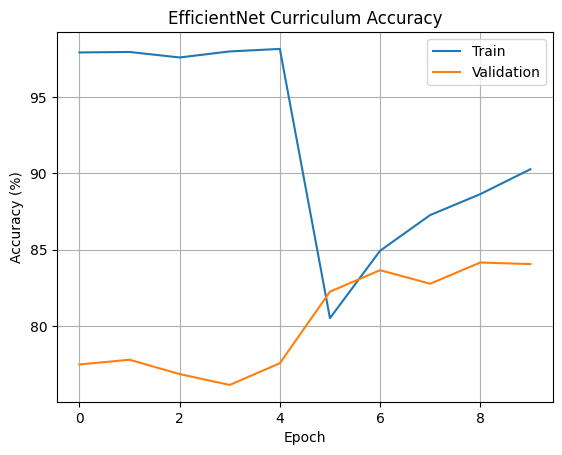

In [41]:
plt.plot(acc_eff, label="Train")
plt.plot(val_acc_eff, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet Curriculum Accuracy")
plt.legend()
plt.grid()
plt.show()

### LOSS GRAPH

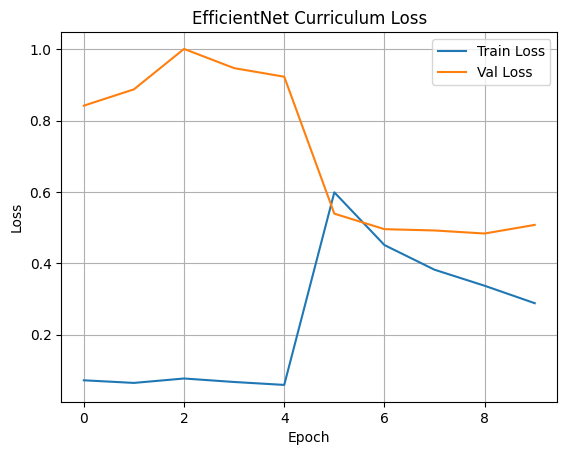

In [42]:
plt.plot(loss_eff, label="Train Loss")
plt.plot(val_loss_eff, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet Curriculum Loss")
plt.legend()
plt.grid()
plt.show()

### PREDICTION

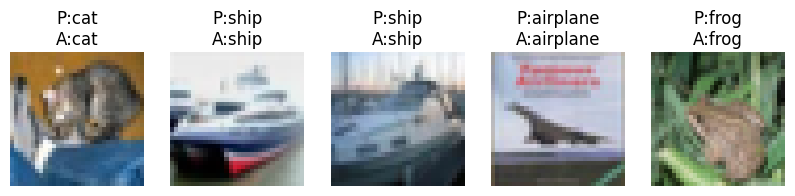

In [43]:
images, labels = next(iter(testloader))

images = images.to(device)

outputs = model_eff(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)

    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)

    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis("off")

plt.show()

## FINAL COMPARISON

In [44]:
print("\nFinal Accuracy Comparison (Curriculum)")
print(f"MobileNet Accuracy: {acc_mob_test:.2f}%")
print(f"EfficientNet Accuracy: {acc_eff_test:.2f}%")


Final Accuracy Comparison (Curriculum)
MobileNet Accuracy: 82.20%
EfficientNet Accuracy: 84.05%


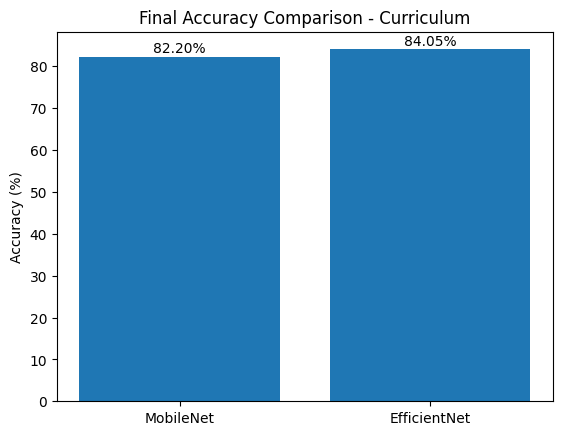

In [45]:
models = ['MobileNet', 'EfficientNet']
accuracies = [acc_mob_test, acc_eff_test]

plt.bar(models, accuracies)
plt.title("Final Accuracy Comparison - Curriculum")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()

## Observation

- Curriculum learning improves performance by training the model from easy to difficult samples.
- It leads to more stable convergence and better generalization.
- EfficientNet outperforms MobileNet due to its superior feature representation.
- Overall, curriculum learning achieves higher accuracy compared to other training strategies.